Code for reading PLE maps

Data - PLE maps for phDADQ concentrations and phDADQ@P2

In [32]:
# ============================================================
# STEP 1: Project Discovery & Robust Metadata 1D/3D Typing
# ============================================================
import os
import originpro as op
import pandas as pd
from dataclasses import dataclass, field

@dataclass
class Measurement:
    name: str                             
    folder_path: str = ""               
    pages: dict = field(default_factory=dict)  
    label: str = None                     
    Note: str = ""                        
    tipo: str = "Unknown"                 # "PLE map" o "Spectra"
    subtipo: str = ""                     # "Excitation (R1)" o "Emission (S2/S1)"
    
    XYZ_df: pd.DataFrame = None           
    PLE_WL: pd.DataFrame = None           
    linear_df: pd.DataFrame = None        
    R1: pd.DataFrame = None               

    def __post_init__(self):
        if self.label is None:
            self.label = self.name

file_path = r"H:\FUBerlin\Measurements\PLE\CristianB\20260618_phDADQ_F006_continuation\20260618_phDADQ_F006_continuation.OPJ"
op.open(file_path)

measurements = {}
books = [x for x in op.pages() if type(x).__name__ == "WBook"]

print(f"Found {len(books)} workbooks in total. Reading and classifying:\n")

for book in books:
    book_name = book.name
    pages = {page.name: page for page in book}
    
    note_text = ""
    if "Note" in pages:
        try:
            note_text = pages["Note"].to_df().iloc[0, 0]
        except Exception:
            note_text = ""

    measurement = Measurement(
        name=book_name,
        pages=pages,
        Note=note_text
    )

    # 1. Check if it's a PLE map
    xyz_page_name = next((p for p in pages if "XYZ" in p), None)
    
    if xyz_page_name is not None:
        measurement.tipo = "PLE map"
        
        if "Data_R1" in pages:
            try:
                df_R1 = pages["Data_R1"].to_df()
                exc_col = pd.to_numeric(df_R1.iloc[:, 0], errors='coerce')
                int_col = pd.to_numeric(df_R1.iloc[:, 1], errors='coerce')
                df_R1_clean = pd.DataFrame({'Exc': exc_col, 'Int': int_col}).dropna()
                measurement.R1 = df_R1_clean.set_index("Exc")
            except Exception:
                pass

        try:
            df_xyz = pages[xyz_page_name].to_df()
            df_xyz.columns = ['Em', 'Exc', 'Int']
            df_xyz = df_xyz.astype(float)
            measurement.XYZ_df = df_xyz
            measurement.PLE_WL = df_xyz.pivot(index="Exc", columns="Em", values="Int")
        except Exception as e:
            print(f"   [Warning] Could not parse {xyz_page_name} for {book_name}: {e}")

    # 2. Check if it's a linear spectrum (contains 'Data')
    elif "Data" in pages:
        measurement.tipo = "Spectra"
        try:
            df_data = pages["Data"].to_df()
            
            # Buscamos las etiquetas en los nombres de las columnas o en las primeras filas de metadatos (Long Name)
            header_text = ""
            # Revisar nombres de columnas de pandas
            col_str = " ".join([str(c) for c in df_data.columns])
            # Revisar las primeras filas (típicamente Long Name o celdas de cabecera)
            row_str = ""
            for r_idx in range(min(3, df_data.shape[0])):
                row_str += " " + " ".join([str(val) for val in df_data.iloc[r_idx, :]])
            
            full_meta = (col_str + " " + row_str).upper()
            
            if "R1" in full_meta:
                measurement.subtipo = "Excitation (R1)"
            elif "S2" in full_meta or "S1" in full_meta:
                # Intentar capturar cuál de las dos es
                sub_tag = "S2" if "S2" in full_meta else "S1"
                measurement.subtipo = f"Emission ({sub_tag})"
            else:
                measurement.subtipo = "Unknown 1D"

            # Limpieza y extracción numérica robusta (saltándose las filas de texto de Origin)
            df_clean = pd.DataFrame()
            # En Origin, los datos numéricos puros suelen estar después de las filas de cabecera (Long Name, Units, etc.)
            # Aplicamos pd.numeric a todo y filtramos los NaN
            x_raw = pd.to_numeric(df_data.iloc[:, 0], errors='coerce')
            y_raw = pd.to_numeric(df_data.iloc[:, 1], errors='coerce')
            
            df_clean['X'] = x_raw
            df_clean['Y'] = y_raw
            measurement.linear_df = df_clean.dropna().set_index("X")
            
        except Exception as e:
            print(f"   [Warning] Could not parse Data for {book_name}: {e}")

    measurements[book_name] = measurement
    globals()[book_name] = measurement
    
    sub_info = f" | Subtipo: {measurement.subtipo}" if measurement.tipo == "Spectra" else ""
    print(f"-> [{measurement.tipo}] {book_name}{sub_info}")

print(f"\nSuccessfully loaded {len(measurements)} measurements.")

Found 28 workbooks in total. Reading and classifying:

-> [Spectra] Excita1 | Subtipo: Excitation (R1)
-> [Spectra] Sd201 | Subtipo: Emission (S2)
-> [Spectra] Sd701 | Subtipo: Emission (S2)
-> [Spectra] Sd2001 | Subtipo: Emission (S2)
-> [Spectra] F006RA1 | Subtipo: Emission (S2)
-> [Spectra] F006FF1 | Subtipo: Emission (S2)
-> [Spectra] F006FF2 | Subtipo: Emission (S2)
-> [PLE map] Md201
-> [PLE map] Md701
-> [PLE map] Md101
-> [PLE map] Md501
-> [PLE map] Md1001
-> [PLE map] MF006b1
-> [Spectra] SLF0061 | Subtipo: Emission (S2)
-> [Spectra] SLF0062 | Subtipo: Emission (S2)
-> [Spectra] SLF0063 | Subtipo: Emission (S2)
-> [Spectra] SLF0064 | Subtipo: Emission (S2)
-> [Spectra] SLF0065 | Subtipo: Emission (S2)
-> [Spectra] SLF0066 | Subtipo: Emission (S2)
-> [Spectra] SLF0067 | Subtipo: Emission (S2)
-> [Spectra] SLF0068 | Subtipo: Emission (S2)
-> [PLE map] Md2001
-> [PLE map] MF006a1
-> [PLE map] MF006c1
-> [PLE map] MF006d1
-> [PLE map] MF0061
-> [PLE map] MF006b2
-> [PLE map] MF00

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. PLOT PLE MAP (With Axis Limits)
# ============================================================
def plot_ple_map(measurement, xlim=None, ylim=None, cmap="viridis", vmin=None, vmax=None, swap_axes=False):
    """
    Plots the 2D PLE map.
    - swap_axes=False: Emission on X-axis, Excitation on Y-axis (Standard).
    - swap_axes=True:  Excitation on X-axis, Emission on Y-axis.
    - xlim & ylim:     Bounds apply to whatever is currently on X and Y respectively.
    """
    if measurement.tipo != "PLE map" or measurement.PLE_WL is None:
        print(f"⚠️ {measurement.label} is not a valid PLE map.")
        return

    PLE = measurement.PLE_WL
    plt.figure(figsize=(6, 5))

    if swap_axes:
        # Excitation on X-axis, Emission on Y-axis
        im = plt.pcolormesh(
            PLE.index,    # Excitation wavelength (nm) -> X axis
            PLE.columns,  # Emission wavelength (nm) -> Y axis
            PLE.values.T, # Transposed intensity matrix
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )
        plt.xlabel("Excitation Wavelength (nm)")
        plt.ylabel("Emission Wavelength (nm)")
    else:
        # Emission on X-axis, Excitation on Y-axis (Default)
        im = plt.pcolormesh(
            PLE.columns,  # Emission wavelength (nm) -> X axis
            PLE.index,    # Excitation wavelength (nm) -> Y axis
            PLE.values,   # Intensity matrix
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )
        plt.xlabel("Emission Wavelength (nm)")
        plt.ylabel("Excitation Wavelength (nm)")

    plt.title(f"PLE Map: {measurement.label}")
    plt.colorbar(im, label="Intensity (a.u.)")

    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.show()


# ============================================================
# 2. PLOT EMISSION SLICE (With xlim for Emission scale)
# ============================================================
def plot_ple_emission_slice(measurement, excitation_target, tolerance=None, xlim=None):
    """
    Plots an Emission profile sliced at an Excitation wavelength.
    - xlim: tuple (xmin, xmax) to match the Emission scale of the map.
    """
    if measurement.tipo != "PLE map" or measurement.PLE_WL is None:
        print(f"⚠️ {measurement.label} is not a valid PLE map.")
        return

    PLE = measurement.PLE_WL
    exc_axis = PLE.index

    if tolerance is not None:
        mask = (exc_axis >= excitation_target - tolerance) & (exc_axis <= excitation_target + tolerance)
        if not mask.any():
            print(f"❌ No excitation points in range {excitation_target} ± {tolerance} nm.")
            return
        
        profile = PLE.loc[mask].mean(axis=0)
        title_desc = f"Emission Profile @ Exc = {excitation_target} ± {tolerance} nm (Integrated)"
    else:
        idx_closest = np.argmin(np.abs(exc_axis - excitation_target))
        actual_exc = exc_axis[idx_closest]
        profile = PLE.iloc[idx_closest]
        title_desc = f"Emission Profile @ Exc ≈ {actual_exc:.1f} nm (Closest)"

    plt.figure(figsize=(6, 4))
    plt.plot(profile.index, profile.values, color="#D55E00", lw=1.5)
    plt.xlabel("Emission Wavelength (nm)")
    plt.ylabel("Intensity (a.u.)")
    plt.title(f"{measurement.label}\n{title_desc}", fontsize=10)
    plt.grid(True, alpha=0.3)

    if xlim is not None:
        plt.xlim(xlim)

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. PLOT EXCITATION SLICE (With xlim for Excitation scale)
# ============================================================
def plot_ple_excitation_slice(measurement, emission_target, tolerance=None, xlim=None):
    """
    Plots an Excitation profile sliced at an Emission wavelength.
    - xlim: tuple (xmin, xmax) to match the Excitation scale of the map.
    """
    if measurement.tipo != "PLE map" or measurement.PLE_WL is None:
        print(f"⚠️ {measurement.label} is not a valid PLE map.")
        return

    PLE = measurement.PLE_WL
    em_axis = PLE.columns

    if tolerance is not None:
        mask = (em_axis >= emission_target - tolerance) & (em_axis <= emission_target + tolerance)
        if not mask.any():
            print(f"❌ No emission points in range {emission_target} ± {tolerance} nm.")
            return
        
        profile = PLE.loc[:, mask].mean(axis=1)
        title_desc = f"Excitation Profile @ Em = {emission_target} ± {tolerance} nm (Integrated)"
    else:
        idx_closest = np.argmin(np.abs(em_axis - emission_target))
        actual_em = em_axis[idx_closest]
        profile = PLE.iloc[:, idx_closest]
        title_desc = f"Excitation Profile @ Em ≈ {actual_em:.1f} nm (Closest)"

    plt.figure(figsize=(6, 4))
    plt.plot(profile.index, profile.values, color="#0072B2", lw=1.5)
    plt.xlabel("Excitation Wavelength (nm)")
    plt.ylabel("Intensity (a.u.)")
    plt.title(f"{measurement.label}\n{title_desc}", fontsize=10)
    plt.grid(True, alpha=0.3)

    if xlim is not None:
        plt.xlim(xlim)

    plt.tight_layout()
    plt.show()


    # Constante de energía ya definida en tu script
hc = 1239.84193  # eV·nm

def plot_stokes_shift(measurement, exc_target, exc_tol, em_target, em_tol):
    """
    Extrae el perfil de excitación y de emisión de un mapa PLE, 
    los convierte a energía (eV) y los plotea juntos en el mismo eje 
    para visualizar el Stokes shift.
    """
    if measurement.tipo != "PLE map" or measurement.PLE_WL is None:
        print(f"⚠️ {measurement.label} no es un mapa PLE válido.")
        return

    PLE = measurement.PLE_WL
    
    # 1. Extraer Perfil de Excitación (con tolerancia)
    em_axis = PLE.columns
    mask_em = (em_axis >= em_target - em_tol) & (em_axis <= em_target + em_tol)
    exc_profile = PLE.loc[:, mask_em].mean(axis=1) # index es excitación (nm)
    
    # Convertir eje X de excitación (nm) a Energía de Excitación (eV)
    # Ojo: E_exc = hc / lambda_exc
    exc_energy = hc / exc_profile.index.values
    exc_intensity = exc_profile.values
    
    # Normalizar intensidades para comparar la separación de picos
    exc_intensity = exc_intensity / np.max(exc_intensity)

    # 2. Extraer Perfil de Emisión (con tolerancia)
    exc_axis = PLE.index
    mask_exc = (exc_axis >= exc_target - exc_tol) & (exc_axis <= exc_target + exc_tol)
    em_profile = PLE.loc[mask_exc].mean(axis=0) # columns es emisión (nm)
    
    # Convertir eje X de emisión (nm) a Energía de Emisión (eV)
    em_energy = hc / em_profile.index.values
    em_intensity = em_profile.values
    
    # Normalizar intensidades
    em_intensity = em_intensity / np.max(em_intensity)

    # 3. Plotear ambos en el mismo gráfico en función de la Energía (eV)
    plt.figure(figsize=(7, 4.5))
    
    # Curva de Excitación (invertimos el orden de energía si es necesario o se plotea directo)
    plt.plot(exc_energy, exc_intensity, color="#0072B2", lw=2, label=f"Excitation (Em @ {em_target}±{em_tol} nm)")
    
    # Curva de Emisión
    plt.plot(em_energy, em_intensity, color="#D55E00", lw=2, label=f"Emission (Exc @ {exc_target}±{exc_tol} nm)")
    
    plt.xlabel("Photon Energy (eV)")
    plt.ylabel("Normalized Intensity (a.u.)")
    plt.title(f"Stokes Shift Comparison: {measurement.label}")
    plt.gca().invert_xaxis()  # Opcional: para que la energía vaya de mayor a menor (izq a der) o viceversa según prefieras
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

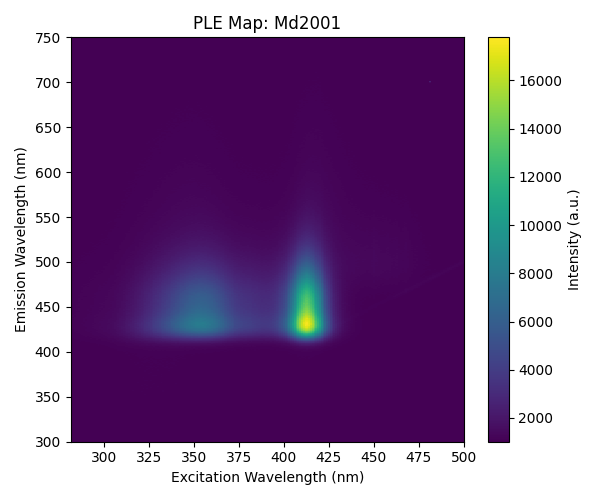

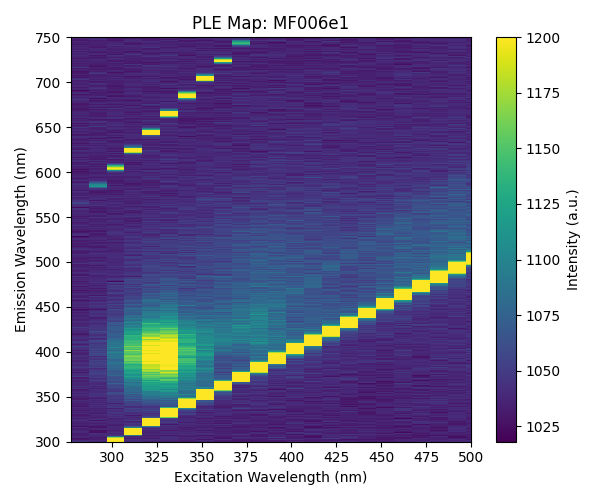

In [113]:
plot_ple_map(Md2001, vmin=None, vmax=None, swap_axes=True, xlim=(None,500), ylim=(300,750))
plot_ple_map(MF006e1, vmin=None, vmax=1200, swap_axes=True, xlim=(None,500), ylim=(300,750))

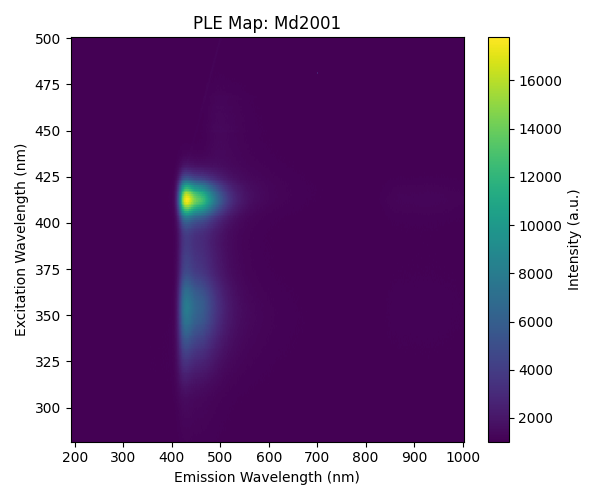

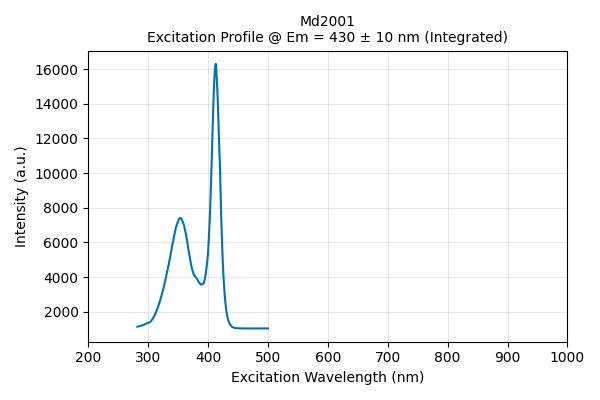

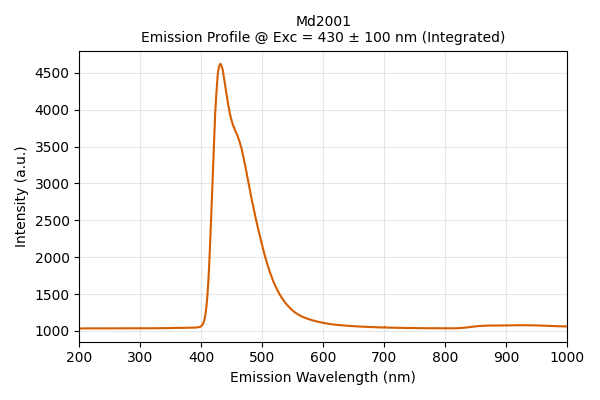

In [69]:
plot_ple_map(Md2001)

# Set scale bounds
em_range = (200, 1000)
exc_range = (200, 1000)

plot_ple_excitation_slice(Md2001, emission_target=430, tolerance=10, xlim=exc_range)
plot_ple_emission_slice(Md2001, excitation_target=430, tolerance=100, xlim=em_range)


plot_stokes_shift(Md2001, excitation_target=430, tolerance=100, emission_target=430, tolerance=10)